# 🏠 Random Forest Regressor — California House Price Prediction

This notebook walks through predicting **continuous house prices** using a **Random Forest Regressor**.

By the end you will understand:
- The difference between **regression** and classification
- How Random Forest extends to regression problems
- How to measure regression quality with **MAE, RMSE, and R²**
- How to interpret the model using **feature importance**

---

## 0 · Regression vs Classification — Key Distinction

Before writing any code, it's important to understand *what kind of problem* we're solving.

| | **Classification** | **Regression** |
|---|---|---|
| **Output** | A category (e.g. disease / no disease) | A continuous number (e.g. house price) |
| **Example** | "Will this patient have heart disease?" | "What will this house sell for?" |
| **Model** | `RandomForestClassifier` | `RandomForestRegressor` |
| **Metrics** | Accuracy, F1, Confusion Matrix | MAE, RMSE, R² |



---

## 0b · How Random Forest Works for Regression

In classification, trees **vote** for a class. In regression, trees output a **number** and the forest **averages** them:

```
         Training Data
              │
    ┌─────────┼─────────┐
    ▼         ▼         ▼
  Tree 1    Tree 2    Tree 3   ← each tree trained on a random bootstrap sample
    │         │         │
  $2.10     $2.50     $2.30   ← each tree predicts a price (in $100k)
    └─────────┼─────────┘
              │
     Average = (2.10 + 2.50 + 2.30) / 3
              │
           $2.30 ✅            ← final prediction
```

**Why average instead of vote?**  
Averaging smooths out individual tree errors. Trees that overestimate are balanced by trees that underestimate — reducing **variance** in the final prediction.

---

## 1 · Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded")

Libraries loaded


## 2 · Load & Explore the Dataset

We use the **California Housing dataset** — built into scikit-learn, no download needed.  
It contains census data from California districts in 1990.

**Target variable:** Median house value for a district (in **100,000**)  
So a target of `2.5` = $250,000.

### Feature Descriptions

| Feature | Description |
|---|---|
| `MedInc` | Median income of households in the district |
| `HouseAge` | Median age of houses in the district |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Total population of the district |
| `AveOccup` | Average number of occupants per household |
| `Latitude` | Geographic latitude of the district |
| `Longitude` | Geographic longitude of the district |

In [3]:
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="MedianHouseValue")

print(f"Dataset shape : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Target range  : ${y.min():.2f} – ${y.max():.2f} (×$100k)")
print(f"Target mean   : ${y.mean():.2f} (×$100k)\n")
X.head()

Dataset shape : 20,640 rows × 8 features
Target range  : $0.15 – $5.00 (×$100k)
Target mean   : $2.07 (×$100k)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### 2a · Exploratory Data Analysis

Always visualise your data before modelling. Three key questions:
1. What does the **target distribution** look like?
2. Which features **correlate** most with house price?
3. Is there any **geographic pattern**?

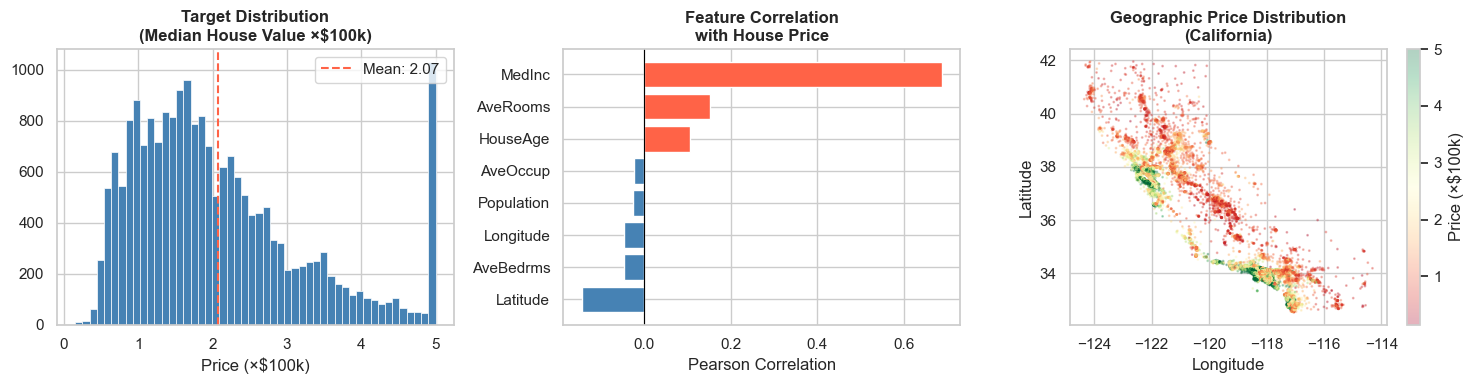

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Target distribution
axes[0].hist(y, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(y.mean(), color='tomato', linestyle='--', label=f'Mean: {y.mean():.2f}')
axes[0].set_title('Target Distribution\n(Median House Value ×$100k)', fontweight='bold')
axes[0].set_xlabel('Price (×$100k)')
axes[0].legend()

# 2. Correlation with target
corr_with_target = X.corrwith(y).sort_values()
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_with_target.values]
axes[1].barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation\nwith House Price', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')

# 3. Geographic scatter
sc = axes[2].scatter(X['Longitude'], X['Latitude'], c=y,
                     cmap='RdYlGn', alpha=0.3, s=1)
plt.colorbar(sc, ax=axes[2], label='Price (×$100k)')
axes[2].set_title('Geographic Price Distribution\n(California)', fontweight='bold')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

## 3 · Train / Test Split

We hold out **20% of the data** as a test set — the model never sees this during training.  
This is how we estimate real-world performance.

> `random_state=42` ensures the same split every time you run the notebook.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")

Training samples : 16,512
Test samples     : 4,128


## 4 · Train the Random Forest Regressor

### Key Hyperparameters

| Parameter | What it controls | Default |
|---|---|---|
| `n_estimators` | Number of trees — more = more stable but slower | 100 |
| `max_depth` | How deep each tree grows — `None` = unlimited | None |
| `min_samples_split` | Min samples needed to split a node | 2 |
| `max_features` | Features considered at each split | `1.0` (all) |
| `random_state` | Seed for reproducibility | — |

> ⏱️ Training 100 trees on ~16,000 samples takes ~30 seconds on CPU.

In [6]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained!")
print(f"   Trees : {model.n_estimators}")
print(f"   Features used : {model.n_features_in_}")

✅ Model trained!
   Trees : 100
   Features used : 8


## 5 · Inspect a Single Prediction

Before running full evaluation, it is useful to sanity-check one prediction manually.

In [7]:
# Pick the first test sample
sample_idx = 0
actual    = y_test.iloc[sample_idx]
predicted = model.predict(X_test.iloc[[sample_idx]])[0]
error     = abs(actual - predicted)

print("Sample features:")
print(X_test.iloc[sample_idx].to_string())
print(f"\nActual price   : ${actual * 100:.1f}k")
print(f"Predicted price: ${predicted * 100:.1f}k")
print(f"Error          : ${error * 100:.1f}k")

Sample features:
MedInc           1.681200
HouseAge        25.000000
AveRooms         4.192201
AveBedrms        1.022284
Population    1392.000000
AveOccup         3.877437
Latitude        36.060000
Longitude     -119.010000

Actual price   : $47.7k
Predicted price: $50.9k
Error          : $3.2k


## 6 · Evaluate the Model

### Regression Metrics — with Equations

Unlike classification (which uses accuracy), regression quality is measured with error-based metrics.

---

#### Mean Absolute Error (MAE)

The **average absolute difference** between predicted and actual values. Easy to interpret — same unit as the target.

$$MAE = \frac{1}{n}\sum_{i=1}^{n}\left|y_i - \hat{y}_i\right|$$

- $y_i$ = actual price for house $i$  
- $\hat{y}_i$ = predicted price for house $i$  
- Lower is better. An MAE of 0.3 means predictions are off by $30,000 on average.

---

#### Root Mean Squared Error (RMSE)

Squares the errors before averaging, so **large errors are penalised more heavily** than small ones.

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2}$$

- Always ≥ MAE. The gap between RMSE and MAE reveals how many large outlier errors exist.
- Lower is better.

---

#### R² Score (Coefficient of Determination)

Measures what **fraction of the variance** in house prices your model explains.

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

- $\bar{y}$ = mean of all actual prices  
- $R^2 = 1.0$ → perfect predictions  
- $R^2 = 0.0$ → model is no better than predicting the mean  
- $R^2 < 0$ → model is worse than the mean (bad!)

---

In [8]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print(f"  MAE       : ${mae:.4f} (×$100k) = ${mae*100:.1f}k avg error")
print(f"  RMSE      : ${rmse:.4f} (×$100k) = ${rmse*100:.1f}k")
print(f"  R² Score  : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print("=" * 40)

  MAE       : $0.3275 (×$100k) = $32.8k avg error
  RMSE      : $0.5053 (×$100k) = $50.5k
  R² Score  : 0.8051  (80.5% variance explained)


## 7 · Actual vs Predicted Plot

A perfect model would place every point exactly on the diagonal line $\hat{y} = y$.  
Points **above** the line = model overestimated; **below** = underestimated.

The spread around the diagonal visually captures RMSE — tighter spread = lower RMSE.

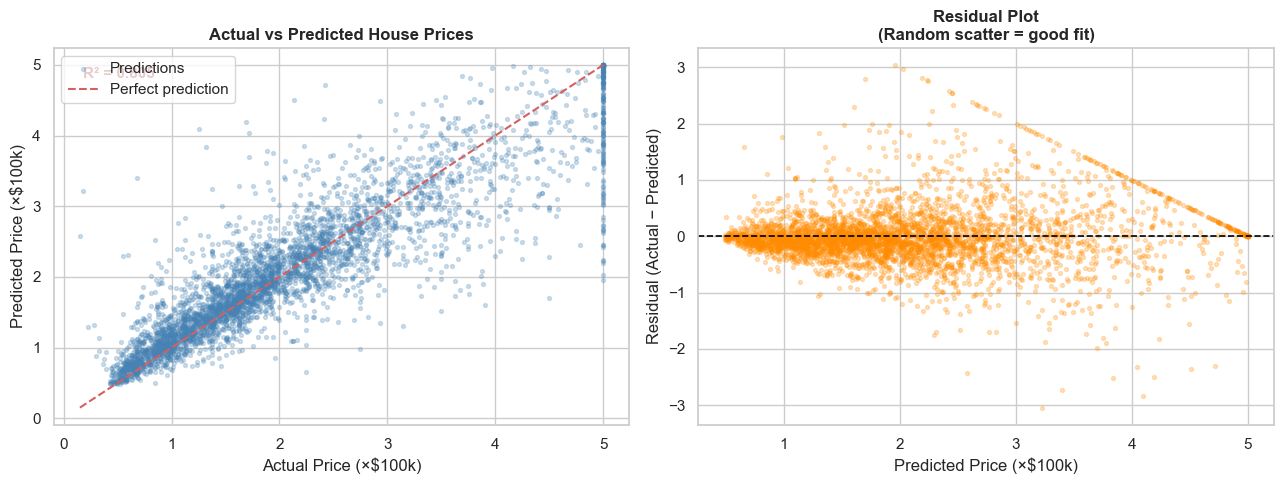

Residuals centred near zero: -0.0124


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: scatter plot ──────────────────────────────────────────────────────
axes[0].scatter(y_test, y_pred, alpha=0.25, s=8, color='steelblue', label='Predictions')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (×$100k)')
axes[0].set_ylabel('Predicted Price (×$100k)')
axes[0].set_title('Actual vs Predicted House Prices', fontweight='bold')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {r2:.3f}', transform=axes[0].transAxes,
             fontsize=11, color='darkred', fontweight='bold')

# ── Right: residual plot ─────────────────────────────────────────────────────
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.25, s=8, color='darkorange')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Price (×$100k)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Plot\n(Random scatter = good fit)', fontweight='bold')

plt.tight_layout()
plt.show()

print("Residuals centred near zero:", f"{residuals.mean():.4f}")

## 8 · Feature Importance

Random Forest can tell us which features were most useful for making accurate predictions.  
The importance score is based on how much each feature **reduces prediction error** (MSE) when used to split nodes, averaged across all trees.

$$\text{Importance}(f) = \frac{1}{T}\sum_{t=1}^{T}\sum_{\text{node } n \text{ splits on } f} \frac{N_n}{N} \cdot \Delta\text{MSE}_n$$

where $T$ = number of trees, $N_n$ = samples at node $n$, $N$ = total samples.

> **Higher importance → the feature reduced error more → more useful for prediction.**

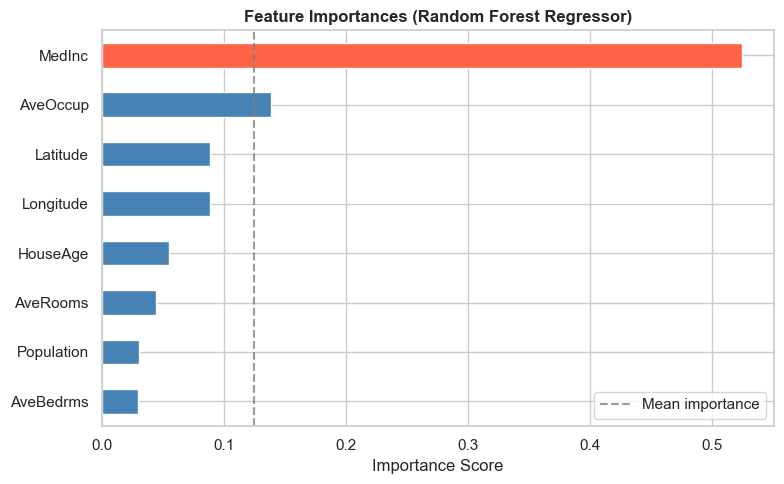

Feature importances (ranked):
MedInc        0.524871
AveOccup      0.138443
Latitude      0.088936
Longitude     0.088629
HouseAge      0.054593
AveRooms      0.044272
Population    0.030650
AveBedrms     0.029606


In [10]:
importances = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v == importances.max() else 'steelblue' for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(importances.mean(), color='gray', linestyle='--', alpha=0.8, label='Mean importance')
ax.set_title('Feature Importances (Random Forest Regressor)', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.show()

print("Feature importances (ranked):")
print(importances.sort_values(ascending=False).to_string())

## 9 · Experiment — How Many Trees Do You Need?

More trees generally improve performance, but with **diminishing returns**.  
This experiment helps you see where adding trees stops helping — useful when training time matters.

> **What to look for:** R² should rise quickly at first, then plateau. That plateau tells you the minimum useful number of trees.

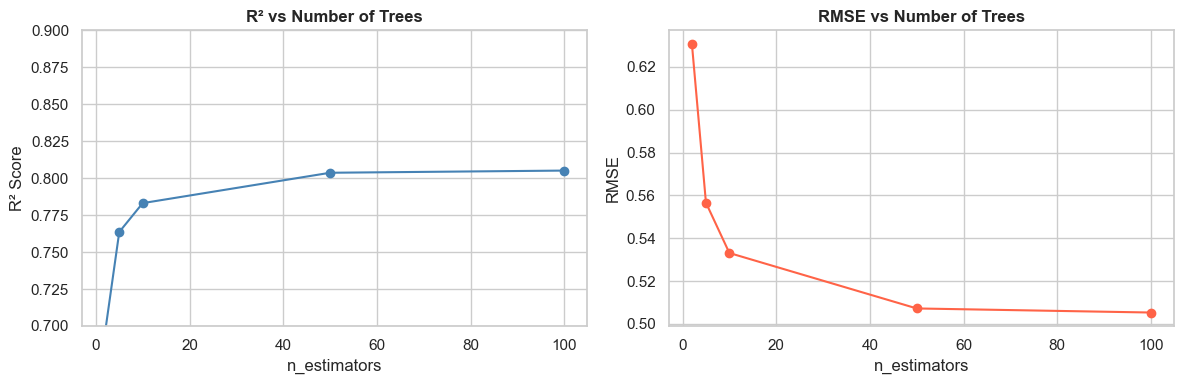

 n_estimators       R²     RMSE
            2 0.696352 0.630796
            5 0.763579 0.556604
           10 0.783104 0.533125
           50 0.803651 0.507245
          100 0.805123 0.505340


In [13]:
# ⏱️ Takes ~3 minute
tree_counts = [2, 5, 10, 50, 100]
results = []

for n in tree_counts:
    m = RandomForestRegressor(n_estimators=n, random_state=42)
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    results.append({
        'n_estimators': n,
        'R²'  : r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds))
    })

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results_df['n_estimators'], results_df['R²'], marker='o', color='steelblue')
axes[0].set_title('R² vs Number of Trees', fontweight='bold')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0.7, 0.9)

axes[1].plot(results_df['n_estimators'], results_df['RMSE'], marker='o', color='tomato')
axes[1].set_title('RMSE vs Number of Trees', fontweight='bold')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))

## 10 · Summary & Key Takeaways

| Step | What we did | Why |
|---|---|---|
| **EDA** | Distribution, correlation, geographic map | Understand the data before modelling |
| **Train/Test split** | 80/20 | Evaluate on unseen data |
| **RandomForestRegressor** | 100 trees, averaged predictions | Robust, low-variance ensemble |
| **MAE** | Average absolute error | Interpretable; same unit as target |
| **RMSE** | Penalises large errors | Reveals outlier mistakes |
| **R² Score** | Variance explained | Overall goodness of fit |
| **Residual plot** | Checks for systematic bias | Good model → random scatter around zero |
| **Feature importance** | Ranks features by error reduction | Interpretability + feature selection |
| **n_estimators experiment** | R² / RMSE vs tree count | Find the sweet spot between speed and accuracy |


### Random Forest Regressor — Pros & Cons

| ✅ Pros | ❌ Cons |
|---|---|
| No feature scaling needed | Slow to train on large datasets |
| Handles non-linear relationships naturally | High memory usage |
| Built-in feature importance | Predictions can't exceed training data range |
| Robust to outliers and noise | Less interpretable than linear regression |
